In [1335]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

In [1336]:
# Plot
plot_directory = 'result/plot_set'

In [1337]:
colors = [
	'#FF0000',
	'#00FFFF',
	'#0000FF',
	'#00008B',
	'#ADD8E6',
	'#800080',
	'#7FFFD4',
	'#008000',
	'#FF00FF',
	'#FFC0CB',
	'#C0C0C0',
	'#FFA500',
	'#000000',
	'#800000',
]

In [1338]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [1339]:
def extract_fpss(metric_list):
	return list(metric_list[list(metric_list.keys())[0]][0]['metric'].keys())

In [1340]:
def to_accuracy_vector(accuracy_result_seq, fpss, type='F1'):
	accuracy_vector = []
	for fps in fpss:
		accuracy_vector.append(accuracy_result_seq[fps][type])
	
	return accuracy_vector

In [1341]:
def plot_scatter(xs, ys, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	plt.scatter(xs, ys, c=colors[0], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [1342]:
def plot_scatter_label(xs, ys, labels, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	for i in range(len(xs)):
		plt.scatter(xs[i], ys[i], c=colors[labels[i]], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [1343]:
def filter_list_index(input_list, indices_to_remove):
	return [item for i, item in enumerate(input_list) if i not in indices_to_remove]

In [1344]:
def round_float_to_sigfigs(number, sigfigs):
	return round(number, sigfigs)

## Plot

In [1345]:
omv_features = ["Left-Top", "Right-Top", "Left-Bottom", "Right-Bottom", "Object-Amount", "Confidence", "IOU"]

In [1346]:
plot_filenames = sorted(os.listdir(plot_directory))
plot_video_names = sorted(list(set([f.split('_')[0] for f in plot_filenames])))

In [1347]:
fpss = extract_fpss(load_json_file(os.path.join(plot_directory, plot_video_names[0] + "_Accuracy_Result.json")))

In [1348]:
omv_videos = []
acc_videos = []

for v in plot_video_names:
	omv_dict = {}
	for fps in fpss:
		omv_dict[fps] = []
	acc_list = []

	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
	movement_result = load_json_file(os.path.join(plot_directory, v + "_Movement_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		for i in range(len(accuracy_result[class_idx])):
			accuracy_vector = to_accuracy_vector(accuracy_result[class_idx][i]['metric'], fpss)
			acc_list.append(accuracy_vector)

			for fps in fpss:
				movement_vector = movement_result[class_idx][i]['movement'][fps]
				omv_dict[fps].append(movement_vector)
	
	omv_videos.append(omv_dict)
	acc_videos.append(acc_list)

In [1349]:
# Corr

# for i in range(len(plot_video_names)):
# 	video_name = plot_video_names[i]
# 	for k in range(len(fpss)):
# 		for j in range(len(omv_videos[0][fpss[0]][0])):	
# 			fps = fpss[k]

# 			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
# 			acc_fps = list(np.array(acc_videos[i])[:, k])

# 			# Remove Outliers
# 			outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
# 			omv_fps_clean = filter_list_index(omv_fps, outlier_index)
# 			acc_fps_clean = filter_list_index(acc_fps, outlier_index)

# 			title = f'{video_name}; OMV Feature {j} ({omv_features[j]}); FPS: {fps}'

# 			correlation_matrix = np.corrcoef(omv_fps_clean, acc_fps_clean)
# 			correlation_coefficient = correlation_matrix[0, 1]
# 			print(f"{title} -> Corr: {round_float_to_sigfigs(correlation_coefficient, 3)}")
# 			# plot_scatter(omv_fps_clean, acc_fps_clean, 'OMV Feature', 'ACC', title)

# 		print("")

# New Code

In [1350]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures

In [1351]:
def transpose_array(arr):
    # Transpose the input array using zip and map it back to a list
    return [list(row) for row in zip(*arr)]

In [1352]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

In [1353]:
def root_mean_squared_error(y_train, y_train_pred):
	return np.sqrt(mean_squared_error(y_train, y_train_pred))

In [1354]:
OMV_FEATURE_INDEX = [4, 6]
TEST_SIZE = 0.2

In [1355]:
# Dataset Build

dataset = {}

for i in range(len(plot_video_names)):
	video_name = plot_video_names[i]
	dataset[video_name] = {}
	
	for k in range(len(fpss)):
		fps = fpss[k]
		dataset[video_name][fps] = {}
		y_all = None
		x_all_t = []

		for j in range(len(omv_videos[0][fpss[0]][0])):	
			fps = fpss[k]

			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
			acc_fps = list(np.array(acc_videos[i])[:, k])

			# Remove Outliers
			outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
			omv_fps_clean = filter_list_index(omv_fps, outlier_index)
			acc_fps_clean = filter_list_index(acc_fps, outlier_index)

			if j == 0:
				y_all = acc_fps_clean.copy()
			if j in OMV_FEATURE_INDEX:
				x_all_t.append(omv_fps_clean.copy())
		
		x_all = transpose_array(x_all_t)
		dataset[video_name][fps]['y_all'] = y_all
		dataset[video_name][fps]['x_all'] = x_all
			

In [1356]:
def lr_inference(x_train, x_test, y_train, y_test):
	lr_model = LinearRegression()
	lr_model.fit(x_train, y_train)

	y_train_pred = lr_model.predict(x_train)
	y_test_pred = lr_model.predict(x_test)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)

	_tr_list = []
	for _p, _y in zip(y_train, y_train_pred):
		_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	plt.figure()
	ax = plt.subplot(211)
	ax.plot(_tr_list)

	_te_list = []
	for _p, _y in zip(y_test, y_test_pred):
		_te_list.append(root_mean_squared_error([_p], [_y]))
	
	bx = plt.subplot(212)
	bx.plot(_te_list)
	plt.show()
	
	# print(f"Linear Regression Train MSE: {round(train_mse, 4)}")
	# print(f"Linear Regression Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

In [1357]:
def pr_inference(x_train, x_test, y_train, y_test):
	poly_train = PolynomialFeatures(degree=3)
	poly_test = PolynomialFeatures(degree=3)
	x_train_poly = poly_train.fit_transform(x_train)
	x_test_poly = poly_test.fit_transform(x_test)

	pr_model = LinearRegression()
	pr_model.fit(x_train_poly, y_train)

	y_train_pred = pr_model.predict(x_train_poly)
	y_test_pred = pr_model.predict(x_test_poly)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)

	_tr_list = []
	for _p, _y in zip(y_train, y_train_pred):
		_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	plt.figure()
	ax = plt.subplot(211)
	ax.plot(_tr_list)

	_te_list = []
	for _p, _y in zip(y_test, y_test_pred):
		_te_list.append(root_mean_squared_error([_p], [_y]))
	
	bx = plt.subplot(212)
	bx.plot(_te_list)
	plt.show()

	# print(f"Polynomial Regression Train MSE: {round(train_mse, 4)}")
	# print(f"Polynomial Regression Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

In [1358]:
def rfr_inference(x_train, x_test, y_train, y_test, ax, bx):
	rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)
	rfr_model.fit(x_train, y_train)

	y_train_pred = rfr_model.predict(x_train)
	y_test_pred = rfr_model.predict(x_test)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)

	_tr_list = []
	for _p, _y in zip(y_train, y_train_pred):
		_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	# plt.figure()
	ax = plt.subplot(211)
	ax.plot(_tr_list)

	_te_list = []
	for _p, _y in zip(y_test, y_test_pred):
		_te_list.append(root_mean_squared_error([_p], [_y]))
	
	bx = plt.subplot(212)
	bx.plot(_te_list)
	plt.show()

	# print(f"Random Forest Regression Train MSE: {round(train_mse, 4)}")
	# print(f"Random Forest Regression Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

In [1359]:
def svr_inference(x_train, x_test, y_train, y_test):
	svr_model = SVR(kernel='rbf', C=1e3, gamma=0.1)
	svr_model.fit(x_train, y_train)

	y_train_pred = svr_model.predict(x_train)
	y_test_pred = svr_model.predict(x_test)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)

	_tr_list = []
	for _p, _y in zip(y_train, y_train_pred):
		_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	plt.figure()
	ax = plt.subplot(211)
	ax.plot(_tr_list)

	_te_list = []
	for _p, _y in zip(y_test, y_test_pred):
		_te_list.append(root_mean_squared_error([_p], [_y]))
	
	bx = plt.subplot(212)
	bx.plot(_te_list)
	plt.show()

	# print(f"Support Vector Regression Train MSE: {round(train_mse, 4)}")
	# print(f"Support Vector Regression Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

In [1360]:
def knn_inference(x_train, x_test, y_train, y_test):
	knn_model = KNeighborsRegressor(n_neighbors=5)  # Using k = 5 neighbors
	knn_model.fit(x_train, y_train)

	y_train_pred = knn_model.predict(x_train)
	y_test_pred = knn_model.predict(x_test)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)

	_tr_list = []
	for _p, _y in zip(y_train, y_train_pred):
		_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	plt.figure()
	ax = plt.subplot(211)
	ax.plot(_tr_list)

	_te_list = []
	for _p, _y in zip(y_test, y_test_pred):
		_te_list.append(root_mean_squared_error([_p], [_y]))
	
	bx = plt.subplot(212)
	bx.plot(_te_list)
	plt.show()

	# print(f"K-Nearest Neighbors Train MSE: {round(train_mse, 4)}")
	# print(f"K-Nearest Neighbors Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

FPS: 1


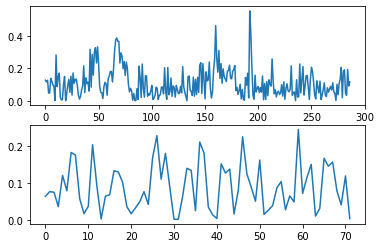

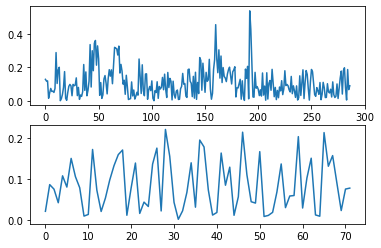

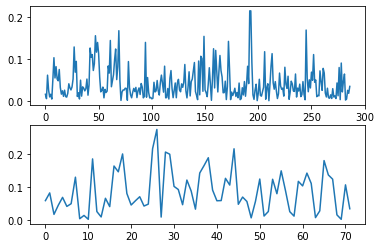

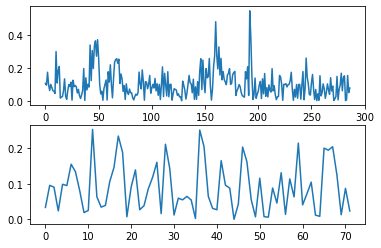

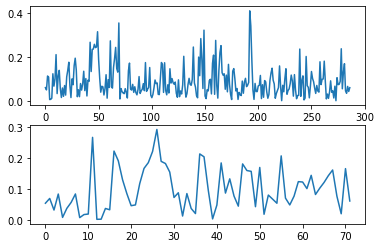

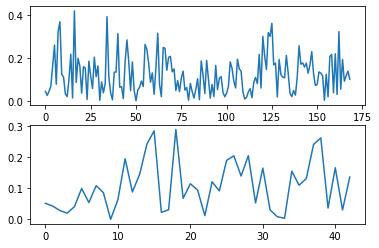

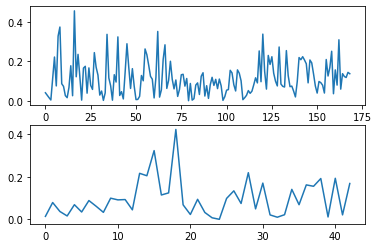

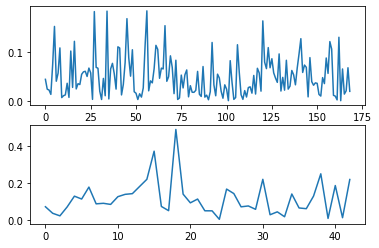

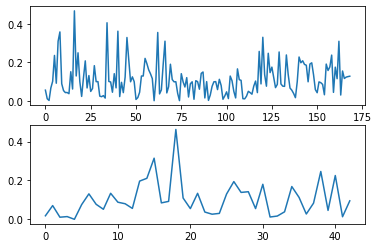

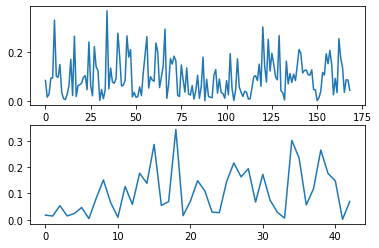

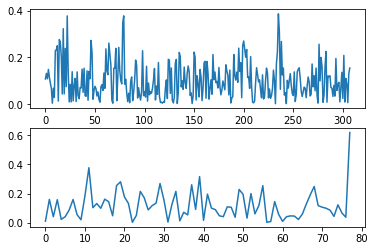

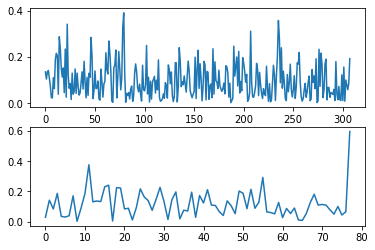

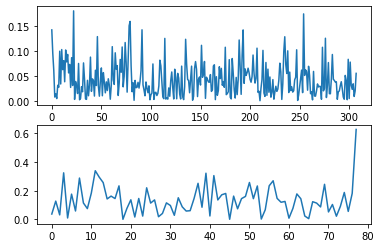

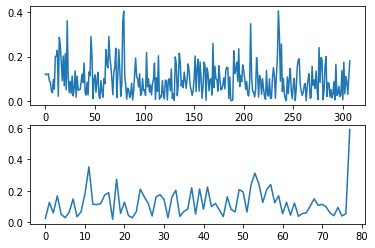

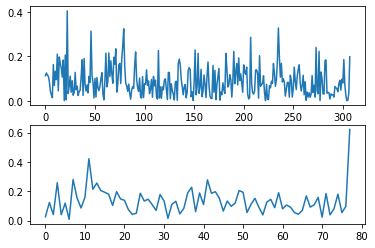

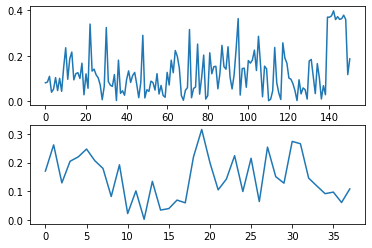

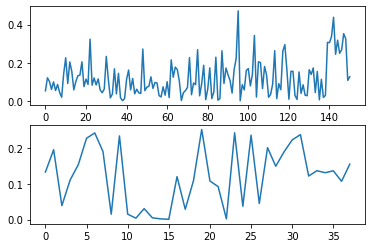

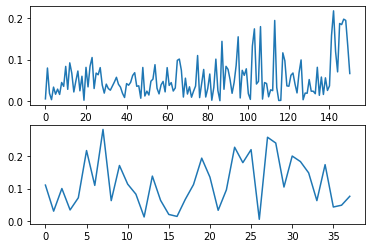

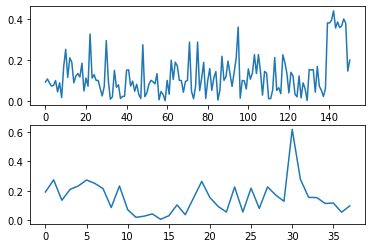

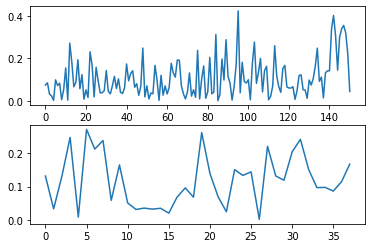

LR
[0.14282679 0.15040799 0.12738439 0.16118175]
[0.11084025 0.13518064 0.15615816 0.167721  ]
PR
[0.13766302 0.14388805 0.12079591 0.15271962]
[0.10553421 0.13300104 0.15021869 0.1488853 ]
RFR
[0.05617762 0.06475118 0.05543935 0.07139326]
[0.10791737 0.14900739 0.17127945 0.13954066]
SVR
[0.13216583 0.14279076 0.12117353 0.15856069]
[0.1138399  0.13843676 0.15463407 0.18964101]
KNN
[0.1123442  0.12330667 0.10959528 0.1397927 ]
[0.12186504 0.13828403 0.16236544 0.14092426]

FPS: 2


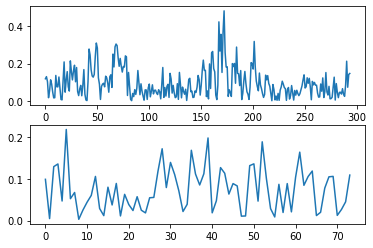

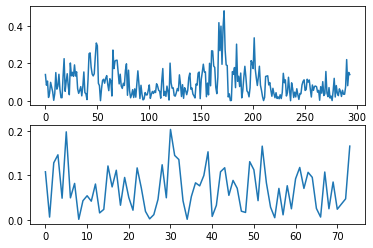

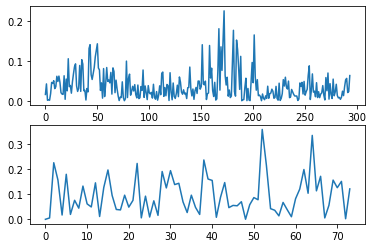

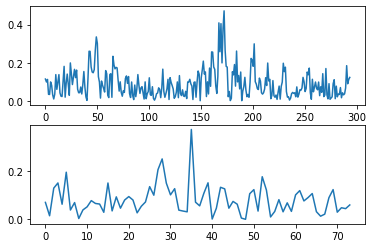

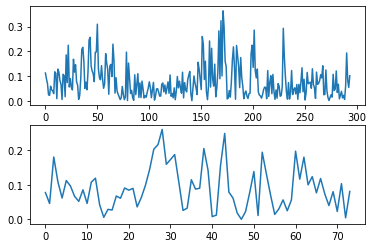

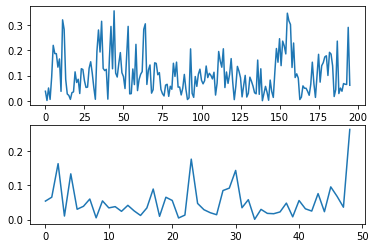

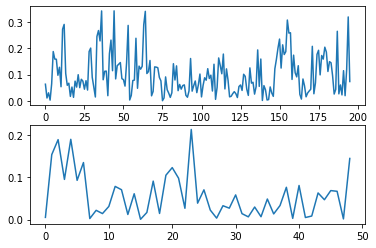

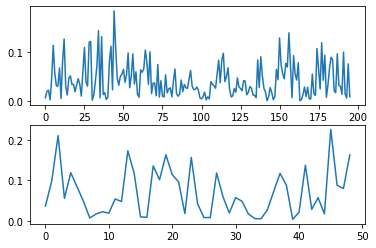

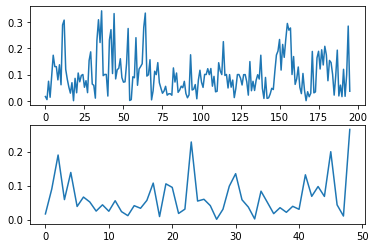

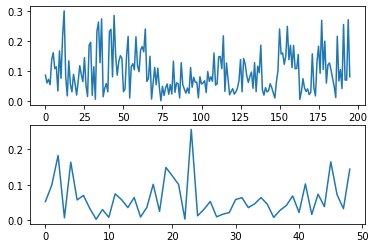

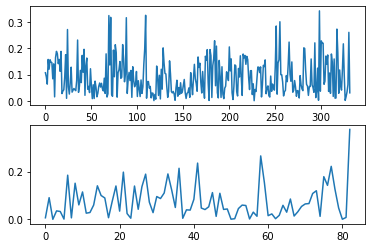

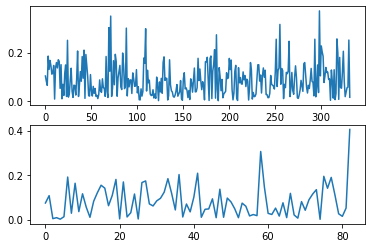

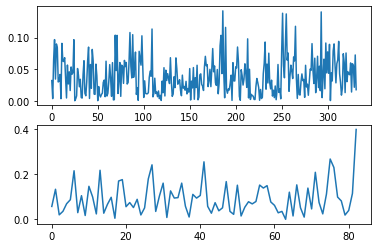

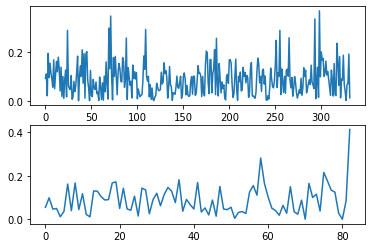

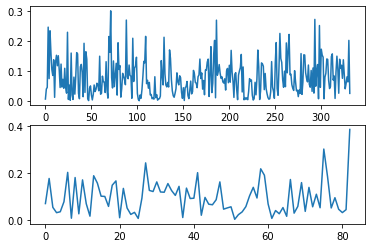

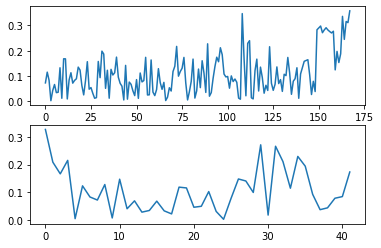

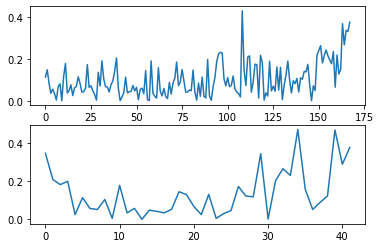

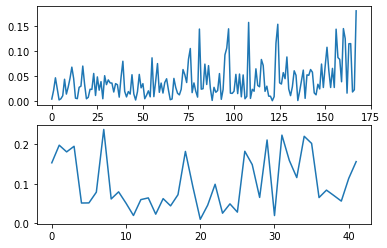

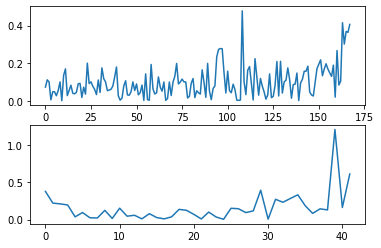

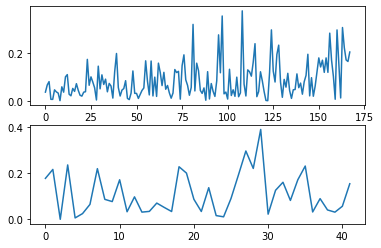

LR
[0.12520299 0.13253109 0.11404306 0.13758081]
[0.0904693  0.07265669 0.10552815 0.13377227]
PR
[0.12195941 0.12720399 0.11007876 0.13138075]
[0.08609944 0.07856943 0.11092543 0.18493401]
RFR
[0.05250548 0.05470877 0.04837147 0.05418405]
[0.12252213 0.09051605 0.11865388 0.12249093]
SVR
[0.11872989 0.12714806 0.10890442 0.13158466]
[0.10232269 0.08775352 0.1127345  0.26055033]
KNN
[0.10414587 0.11706099 0.09825569 0.11544217]
[0.11031899 0.08115166 0.11942638 0.14440113]

FPS: 3


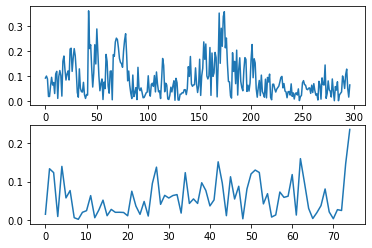

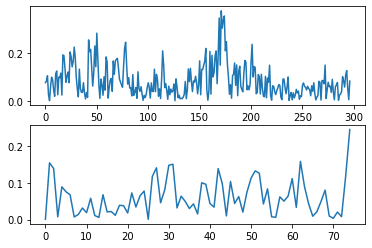

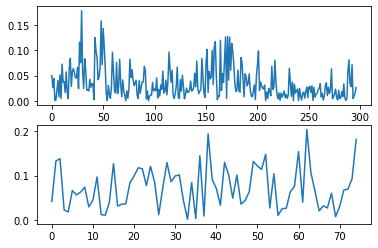

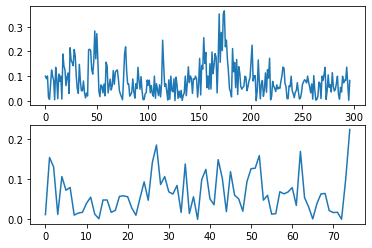

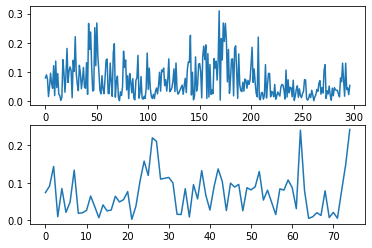

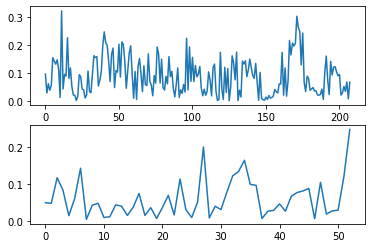

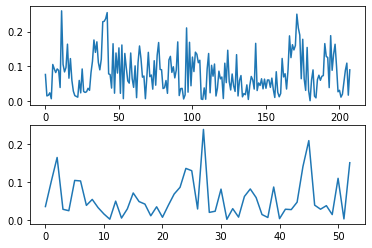

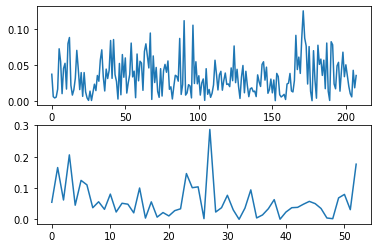

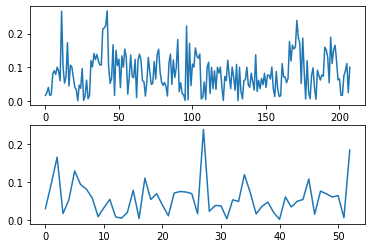

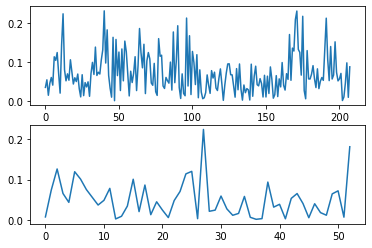

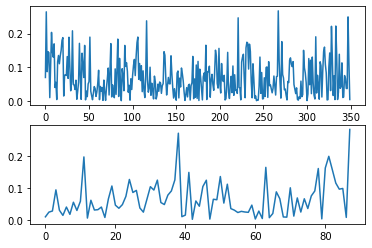

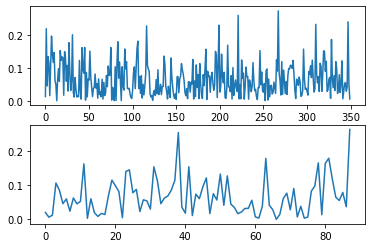

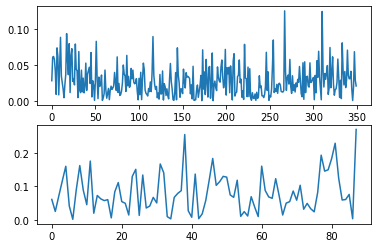

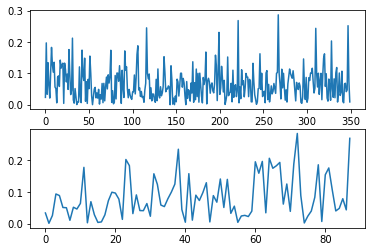

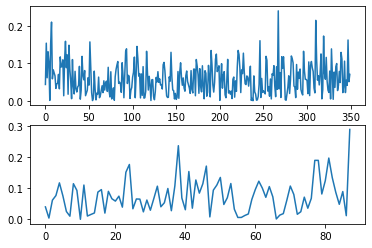

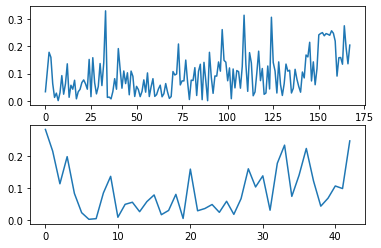

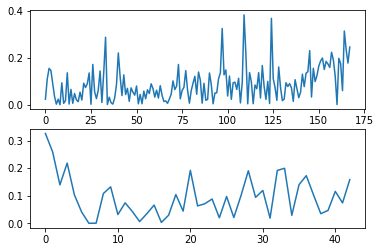

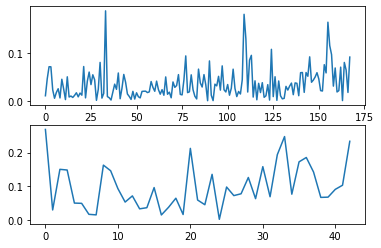

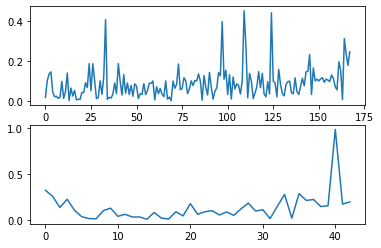

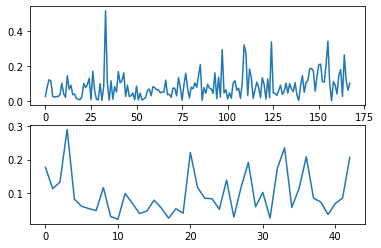

LR
[0.11240265 0.11149758 0.08846565 0.1205126 ]
[0.07615597 0.07976888 0.08825454 0.11774237]
PR
[0.1087157  0.09861619 0.0821608  0.11485996]
[0.0780494  0.07768732 0.08675051 0.12099227]
RFR
[0.04699826 0.04246531 0.03487836 0.0479348 ]
[0.08717243 0.08075404 0.10073348 0.11970505]
SVR
[0.10581335 0.09944641 0.08251024 0.11722536]
[0.08064195 0.07424084 0.10870837 0.20590564]
KNN
[0.09331704 0.08717672 0.07165673 0.11203175]
[0.09156933 0.06892563 0.09442418 0.11732309]

FPS: 5


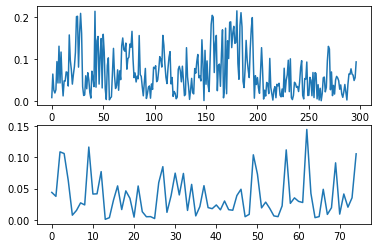

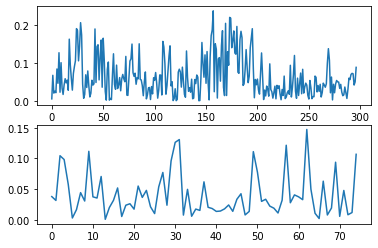

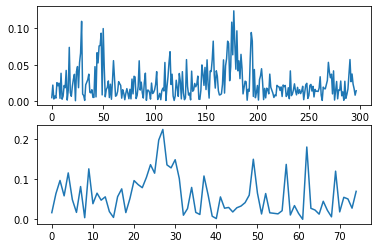

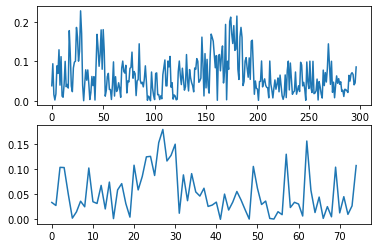

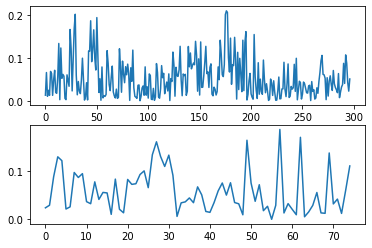

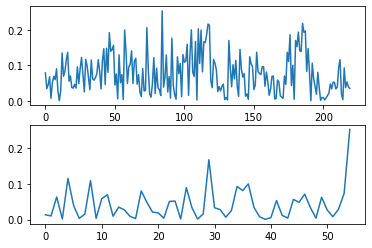

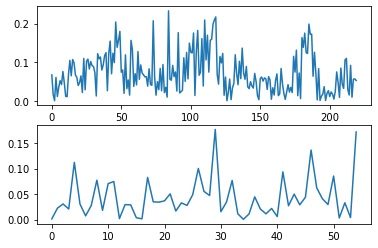

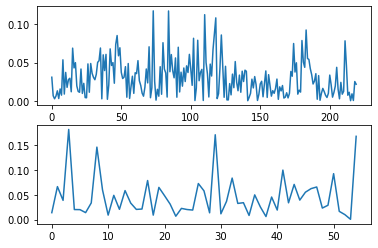

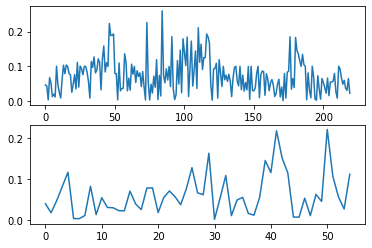

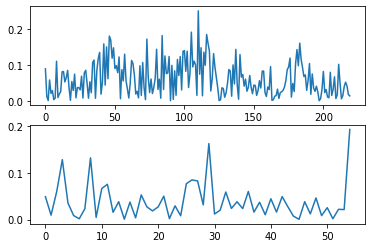

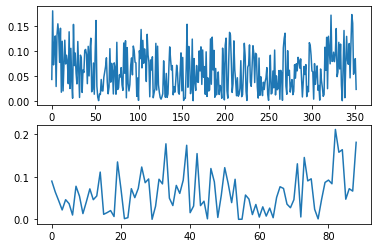

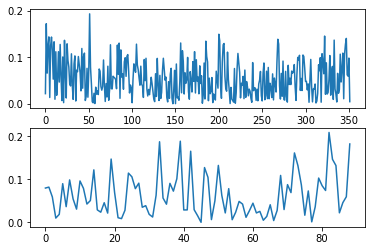

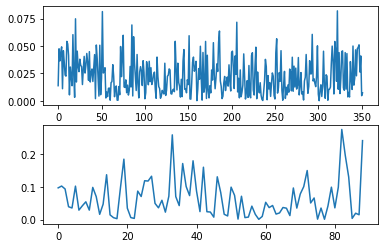

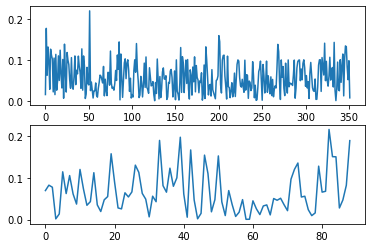

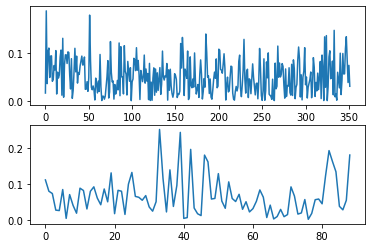

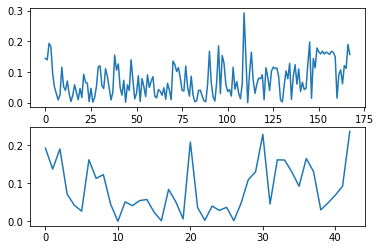

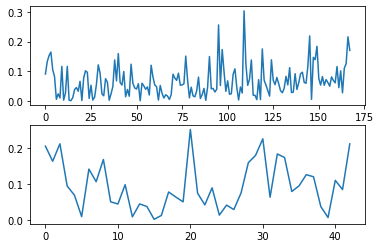

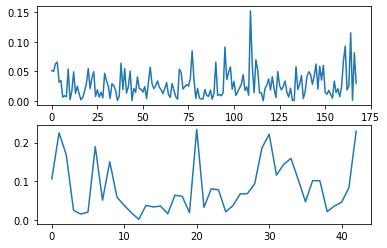

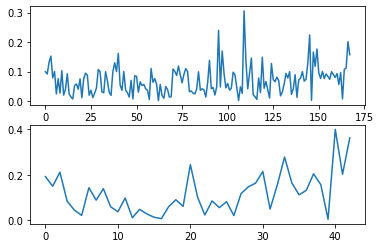

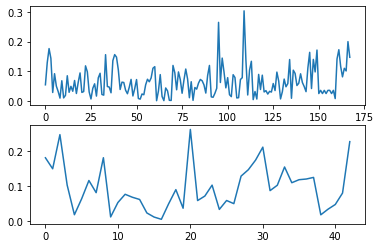

LR
[0.08525442 0.09483699 0.07265092 0.09316856]
[0.04994891 0.06192538 0.07920983 0.10848724]
PR
[0.08205586 0.08908079 0.06723295 0.08356961]
[0.0540934  0.0582972  0.08064732 0.11764268]
RFR
[0.03273326 0.03859627 0.02791953 0.03621591]
[0.07781343 0.06222285 0.08975176 0.10746815]
SVR
[0.07963006 0.08954163 0.0681534  0.08506659]
[0.06965317 0.08011818 0.08401975 0.14859669]
KNN
[0.06885293 0.07824133 0.06120664 0.08143314]
[0.07372327 0.05562273 0.08682267 0.11588804]

FPS: 6


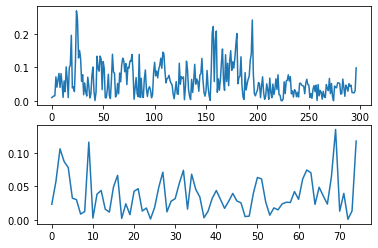

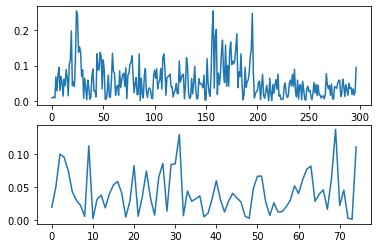

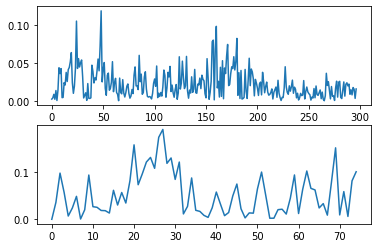

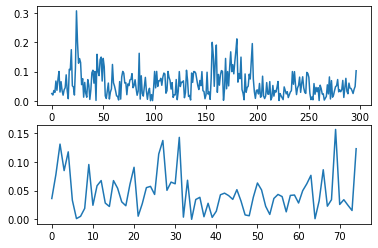

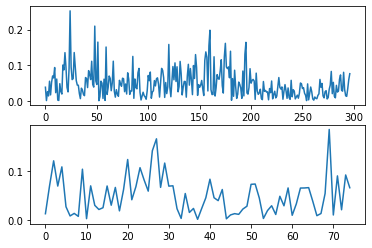

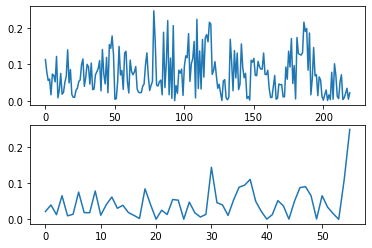

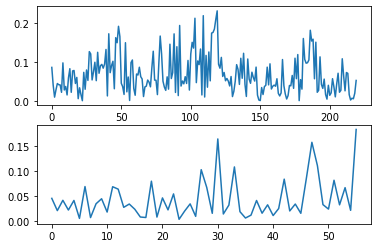

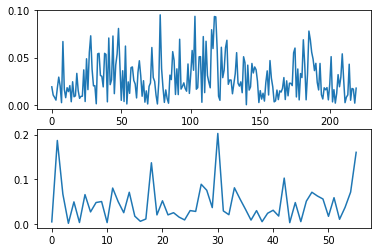

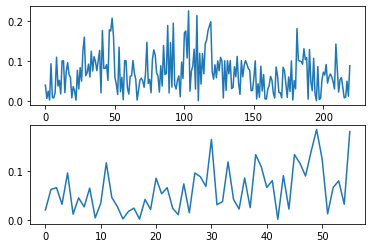

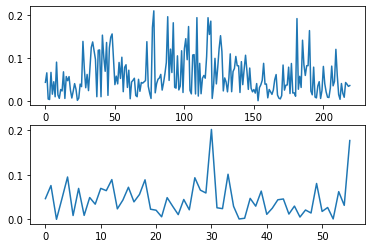

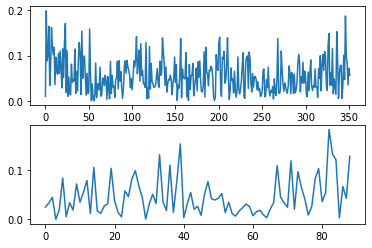

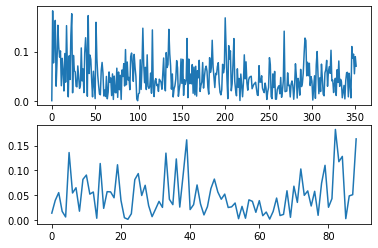

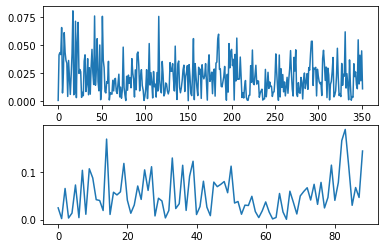

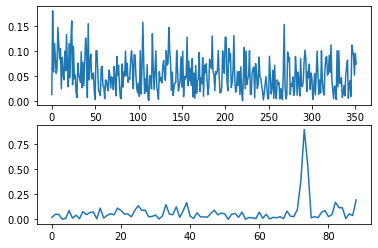

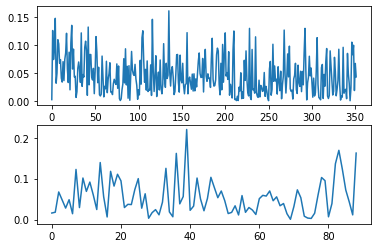

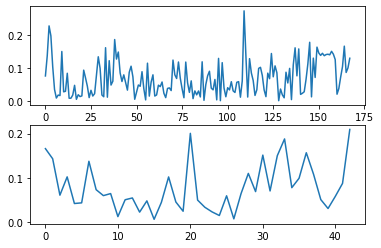

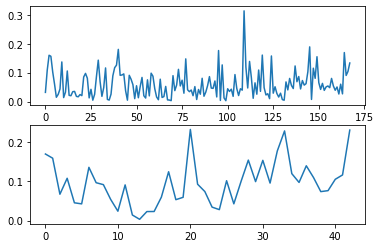

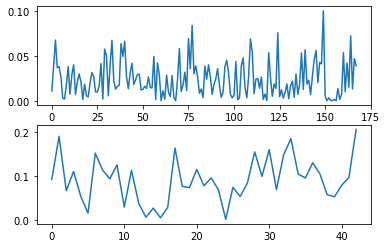

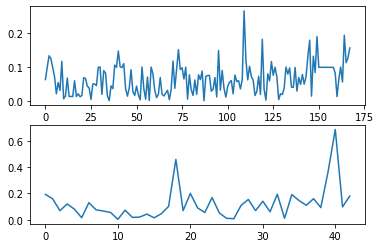

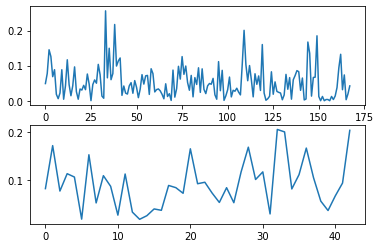

LR
[0.07620165 0.09258025 0.06722228 0.08684665]
[0.04719841 0.06138122 0.06146829 0.0949853 ]
PR
[0.07351999 0.08409339 0.06185569 0.07663354]
[0.05285342 0.05997959 0.06441745 0.11162367]
RFR
[0.02903678 0.03541469 0.02631877 0.03115495]
[0.06994477 0.06343708 0.06749895 0.10433091]
SVR
[0.07299537 0.08497269 0.06318777 0.07882726]
[0.05885082 0.07862373 0.13524741 0.17311188]
KNN
[0.06207093 0.07536091 0.05649533 0.06899465]
[0.06446529 0.05956554 0.07067947 0.10581634]

FPS: 10


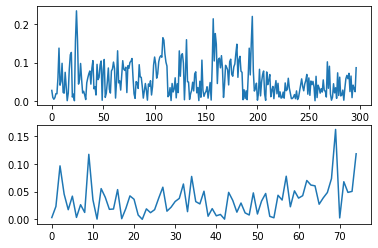

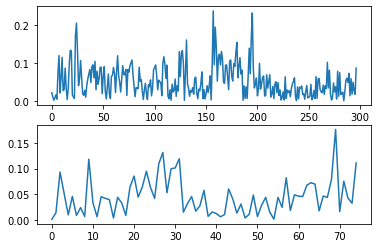

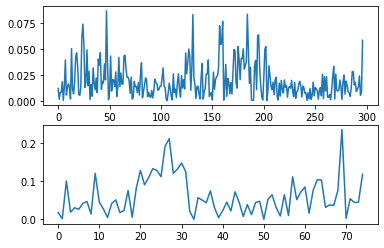

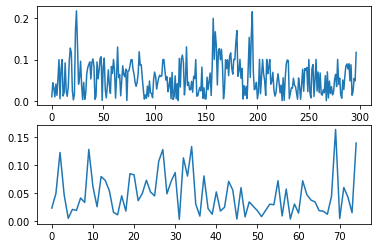

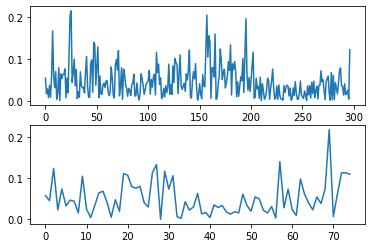

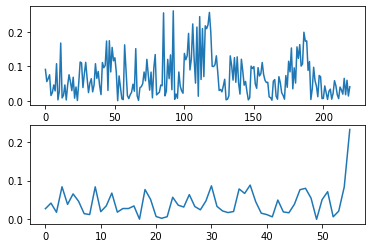

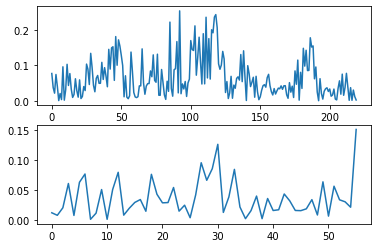

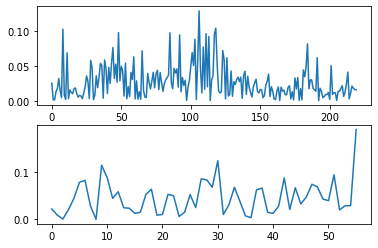

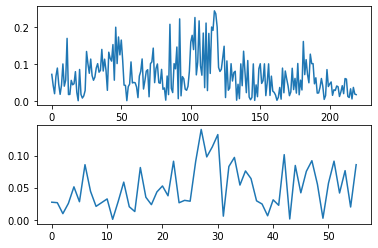

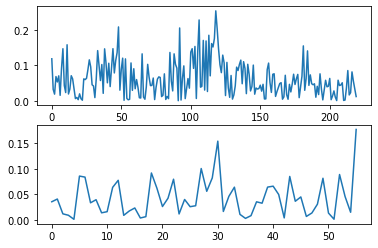

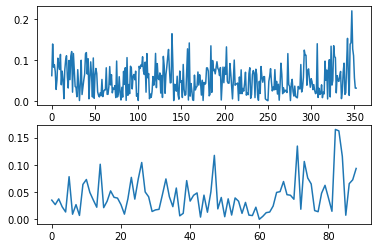

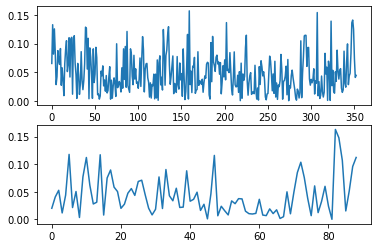

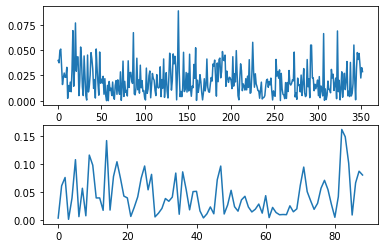

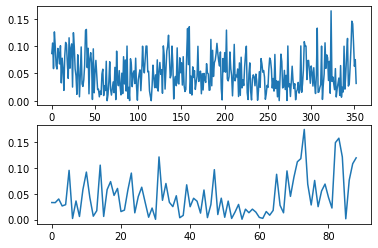

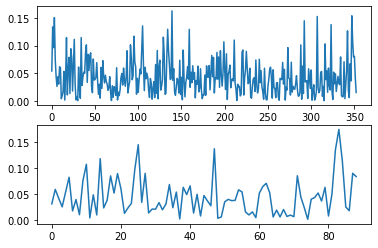

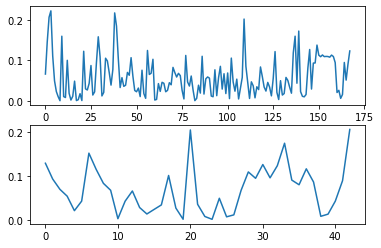

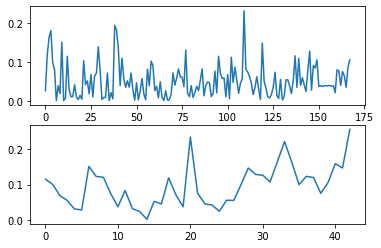

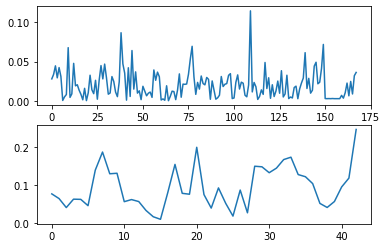

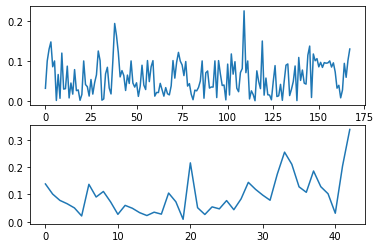

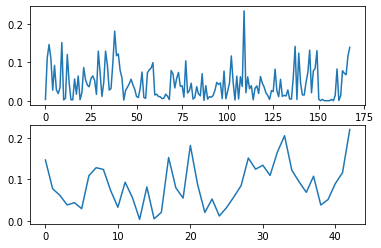

LR
[0.06915855 0.09080874 0.06401007 0.07565673]
[0.04673749 0.05619822 0.05535219 0.08842515]
PR
[0.0664472  0.08582573 0.05848573 0.06659899]
[0.05780291 0.04805006 0.05659941 0.112642  ]
RFR
[0.02520555 0.03628699 0.02535615 0.02707952]
[0.07894703 0.05799201 0.05689008 0.10765365]
SVR
[0.06920286 0.08688685 0.06094149 0.07200286]
[0.0604524  0.06136384 0.06038685 0.12049025]
KNN
[0.05969562 0.08001352 0.05338371 0.0614527 ]
[0.06602821 0.05653077 0.05747279 0.10196734]

FPS: 15


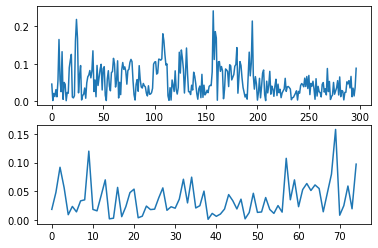

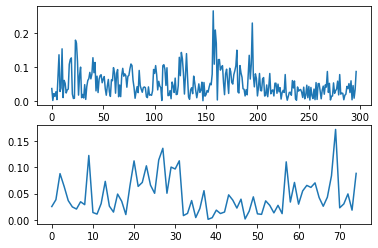

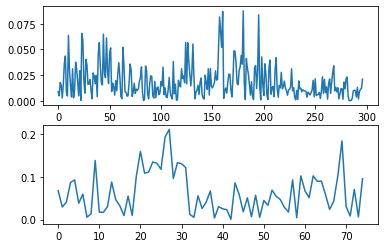

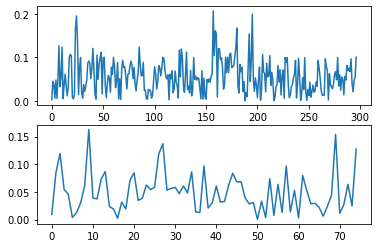

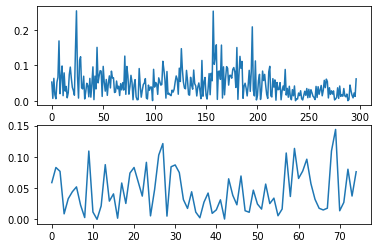

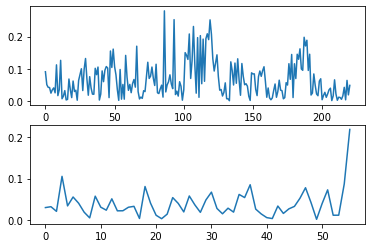

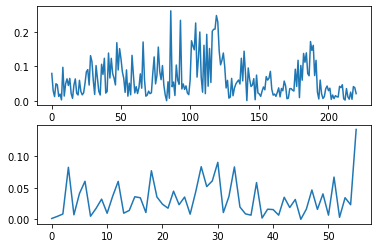

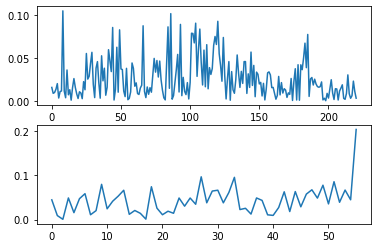

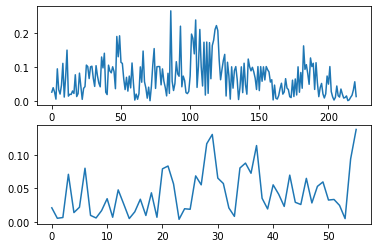

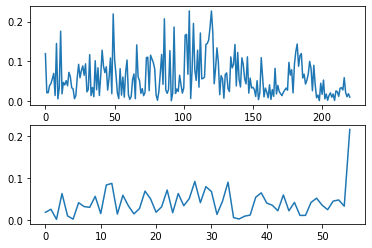

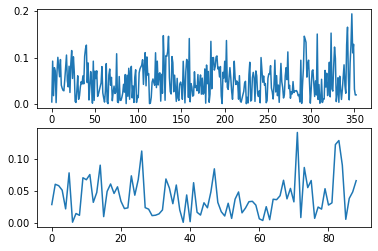

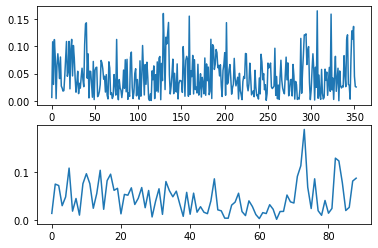

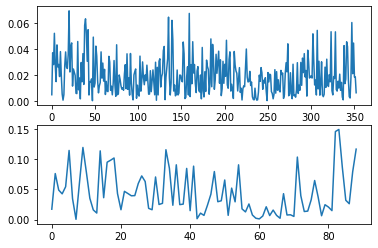

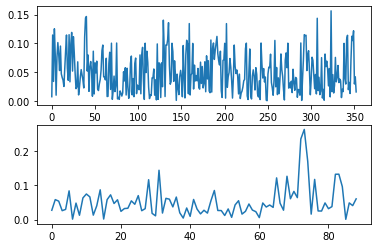

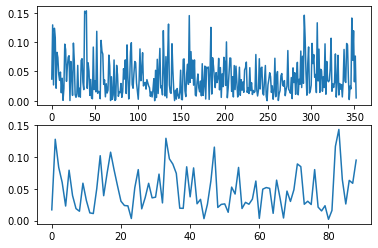

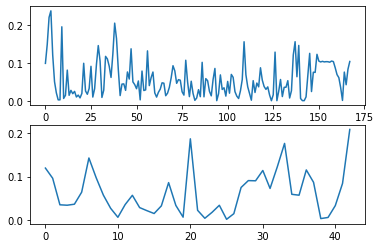

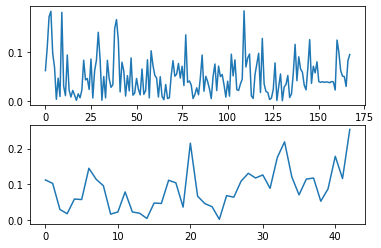

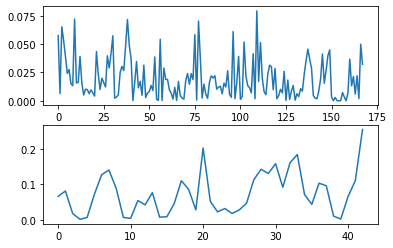

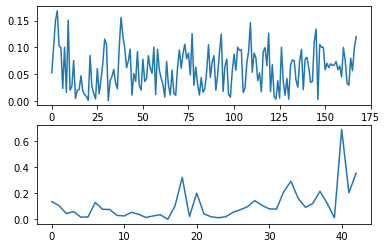

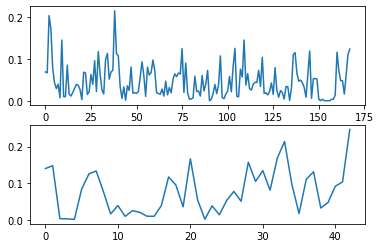

LR
[0.06848612 0.0876993  0.06200871 0.07379512]
[0.04689114 0.05139928 0.05061469 0.08138353]
PR
[0.06547532 0.08430368 0.05765974 0.06450497]
[0.05876517 0.0427433  0.05721812 0.10660943]
RFR
[0.02468677 0.03482512 0.02380756 0.02617104]
[0.07925658 0.05430751 0.05743521 0.09588313]
SVR
[0.06805011 0.08584887 0.06014578 0.07049967]
[0.06135601 0.055441   0.06967563 0.16573918]
KNN
[0.06065951 0.07710625 0.05224089 0.06131288]
[0.05749878 0.05342375 0.05837847 0.09872561]

FPS: 30


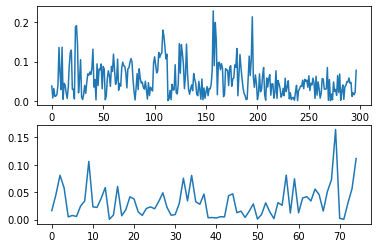

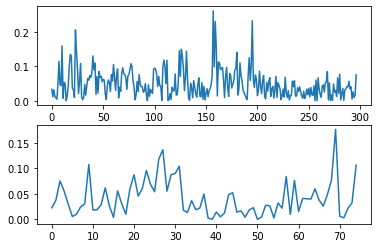

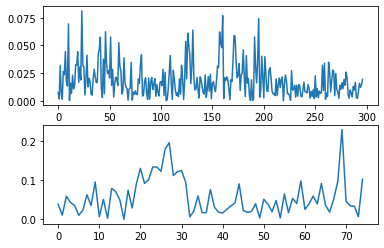

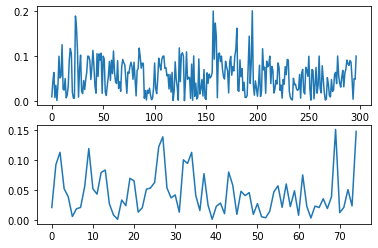

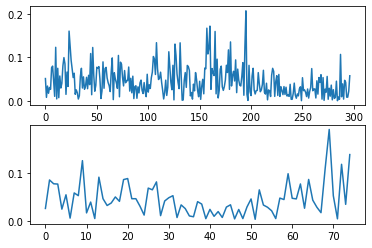

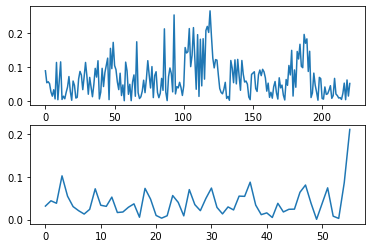

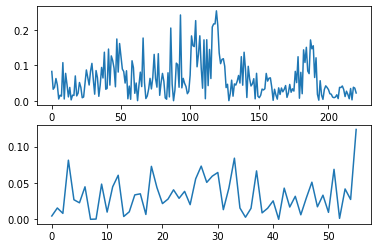

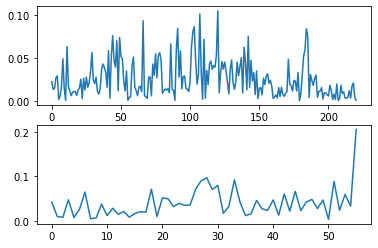

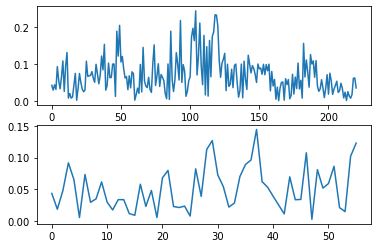

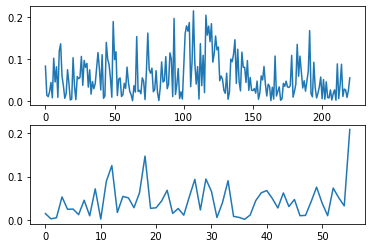

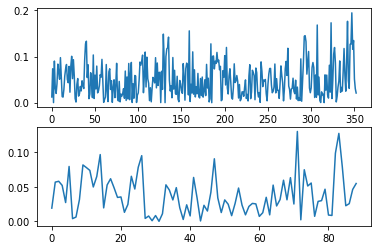

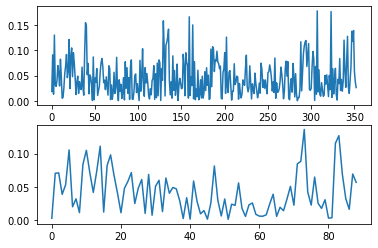

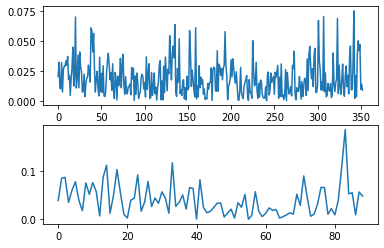

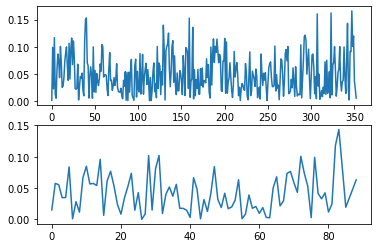

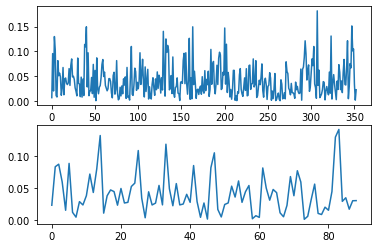

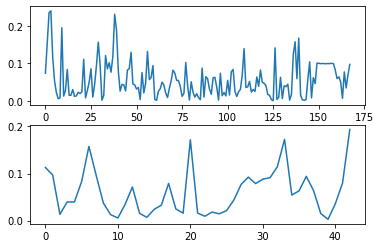

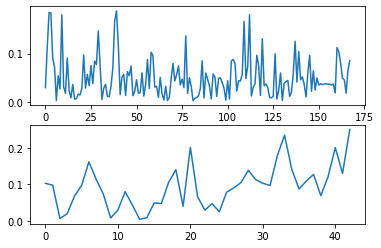

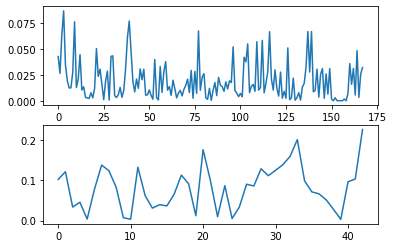

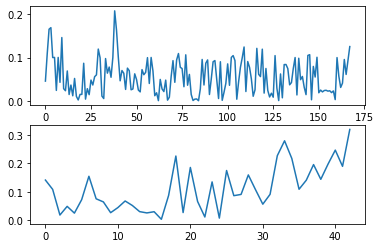

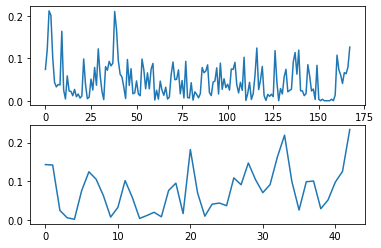

LR
[0.06756675 0.08673155 0.06198629 0.07399877]
[0.04399917 0.0521521  0.04822268 0.07787899]
PR
[0.06454095 0.08345306 0.05823147 0.06450991]
[0.0544557  0.04189122 0.05248689 0.11108473]
RFR
[0.02385484 0.03365666 0.02363423 0.02661895]
[0.07404117 0.05205121 0.05262897 0.09845345]
SVR
[0.0679005  0.08630085 0.06070616 0.06868589]
[0.05860957 0.06185069 0.05238202 0.13691708]
KNN
[0.0567395  0.07528287 0.05237464 0.0633054 ]
[0.0571075  0.05904124 0.05164509 0.09724942]



In [1361]:
for k in range(len(fpss)):
	fps = fpss[k]

	print(f"FPS: {fps}")

	lr_train_mse_list = []
	lr_test_mse_list = []
	pr_train_mse_list = []
	pr_test_mse_list = []
	rfr_train_mse_list = []
	rfr_test_mse_list = []
	svr_train_mse_list = []
	svr_test_mse_list = []
	knn_train_mse_list = []
	knn_test_mse_list = []
	for i in range(len(plot_video_names)):
		video_name = plot_video_names[i]	

		x_all = dataset[video_name][fps]['x_all']
		y_all = dataset[video_name][fps]['y_all']

		x_train, x_test, y_train, y_test = my_train_test_split(x_all, y_all, TEST_SIZE)

		# LR
		lr_train_mse, lr_test_mse = lr_inference(x_train, x_test, y_train, y_test)
		lr_train_mse_list.append(lr_train_mse)
		lr_test_mse_list.append(lr_test_mse)

		# PR
		pr_train_mse, pr_test_mse = pr_inference(x_train, x_test, y_train, y_test)
		pr_train_mse_list.append(pr_train_mse)
		pr_test_mse_list.append(pr_test_mse)

		# RFR
		rfr_train_mse, rfr_test_mse = rfr_inference(x_train, x_test, y_train, y_test)
		rfr_train_mse_list.append(rfr_train_mse)
		rfr_test_mse_list.append(rfr_test_mse)

		# SVR
		svr_train_mse, svr_test_mse = svr_inference(x_train, x_test, y_train, y_test)
		svr_train_mse_list.append(svr_train_mse)
		svr_test_mse_list.append(svr_test_mse)

		# KNN
		knn_train_mse, knn_test_mse = knn_inference(x_train, x_test, y_train, y_test)
		knn_train_mse_list.append(knn_train_mse)
		knn_test_mse_list.append(knn_test_mse)
	
	print(f"LR")
	# print(round(np.sqrt(np.average(np.array(lr_train_mse_list))), 4))
	# print(round(np.sqrt(np.average(np.array(lr_test_mse_list))), 4))
	print(np.array(lr_train_mse_list))
	print(np.array(lr_test_mse_list))

	print(f"PR")
	# print(round(np.sqrt(np.average(np.array(pr_train_mse_list))), 4))
	# print(round(np.sqrt(np.average(np.array(pr_test_mse_list))), 4))
	print(np.array(pr_train_mse_list))
	print(np.array(pr_test_mse_list))

	print(f"RFR")
	# print(round(np.sqrt(np.average(np.array(rfr_train_mse_list))), 4))
	# print(round(np.sqrt(np.average(np.array(rfr_test_mse_list))), 4))
	print(np.array(rfr_train_mse_list))
	print(np.array(rfr_test_mse_list))

	print(f"SVR")
	# print(round(np.sqrt(np.average(np.array(svr_train_mse_list))), 4))
	# print(round(np.sqrt(np.average(np.array(svr_test_mse_list))), 4))
	print(np.array(svr_train_mse_list))
	print(np.array(svr_test_mse_list))
	
	print(f"KNN")
	# print(round(np.sqrt(np.average(np.array(knn_train_mse_list))), 4))
	# print(round(np.sqrt(np.average(np.array(knn_test_mse_list))), 4))
	print(np.array(knn_train_mse_list))
	print(np.array(knn_test_mse_list))

	print(f"")